<a href="https://colab.research.google.com/github/Nandini-9908/ml_project/blob/main/ecg_claude1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
pip install wfdb numpy matplotlib

**single record validation**

In [ ]:
import wfdb

# Downloads record 100 (signal + header + annotations) to a local folder
wfdb.dl_database('mitdb', dl_dir='mitdb_data', records=['100'])

Generating record list for: 100
Generating list of all files for: 100
Finished downloading files


Signal shape: (650000, 2)
Sampling rate: 360
Channel names: ['MLII', 'V5']
Number of annotated beats: 2274
First 20 beat symbols: ['+', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N']
First 20 beat sample indices: [  18   77  370  662  946 1231 1515 1809 2044 2402 2706 2998 3282 3560
 3862 4170 4466 4764 5060 5346]


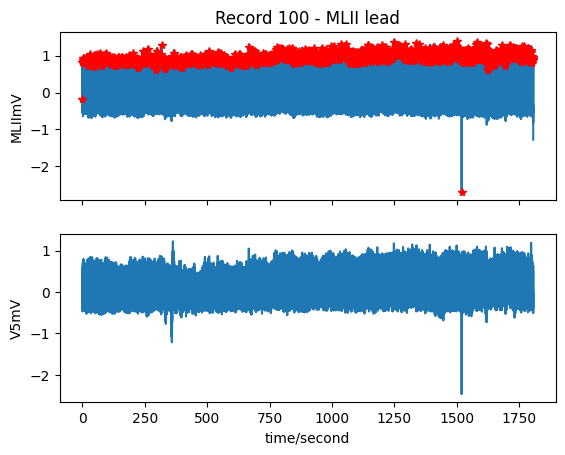

Counter({'N': 2239, 'A': 33, '+': 1, 'V': 1})


In [ ]:
record = wfdb.rdrecord('mitdb_data/100')
annotation = wfdb.rdann('mitdb_data/100', 'atr')

print("Signal shape:", record.p_signal.shape)   # (samples, channels)
print("Sampling rate:", record.fs)
print("Channel names:", record.sig_name)
print("Number of annotated beats:", len(annotation.sample))
print("First 20 beat symbols:", annotation.symbol[:20])
print("First 20 beat sample indices:", annotation.sample[:20])

import matplotlib.pyplot as plt

wfdb.plot_wfdb(record=record, annotation=annotation,
               title='Record 100 - MLII lead',
               time_units='seconds')

from collections import Counter
print(Counter(annotation.symbol))

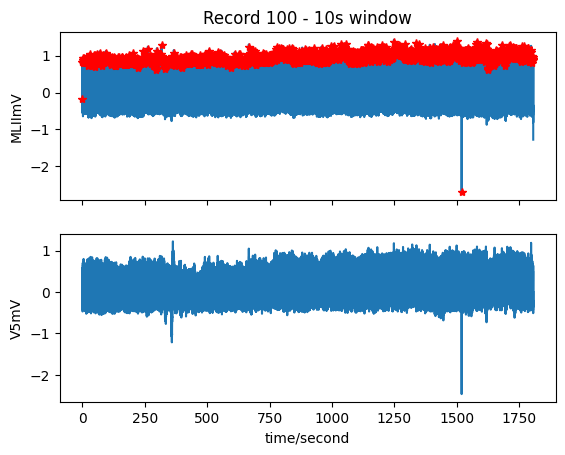

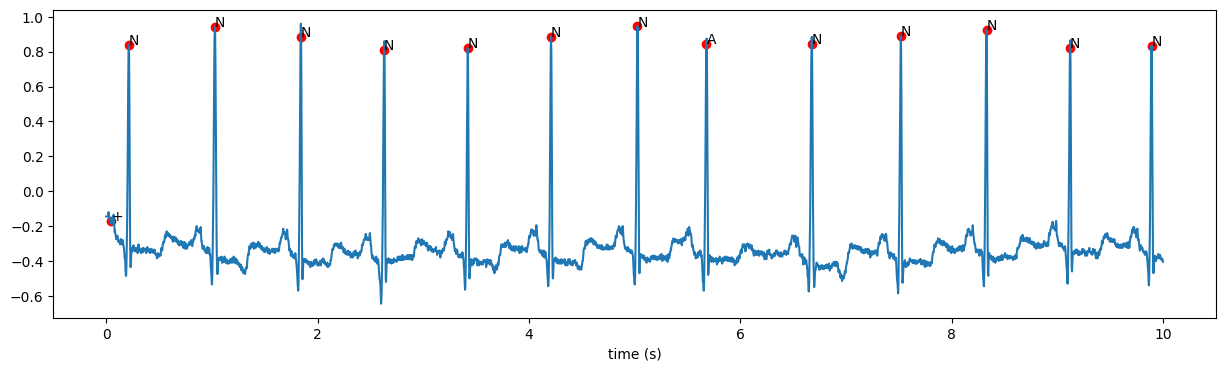

In [ ]:
wfdb.plot_wfdb(record=record, annotation=annotation,
               title='Record 100 - 10s window',
               time_units='seconds')

import numpy as np

start, end = 0, 3600  # first 10 seconds (360 Hz * 10)
sig = record.p_signal[start:end, 0]  # MLII channel
time = np.arange(start, end) / record.fs

# find annotations within this window
mask = (annotation.sample >= start) & (annotation.sample < end)
ann_samples = annotation.sample[mask]
ann_symbols = np.array(annotation.symbol)[mask]

plt.figure(figsize=(15, 4))
plt.plot(time, sig)
plt.scatter(ann_samples / record.fs, sig[ann_samples - start], color='red', marker='o')
for s, sym in zip(ann_samples, ann_symbols):
    plt.annotate(sym, (s / record.fs, sig[s - start]))
plt.xlabel('time (s)')
plt.show()

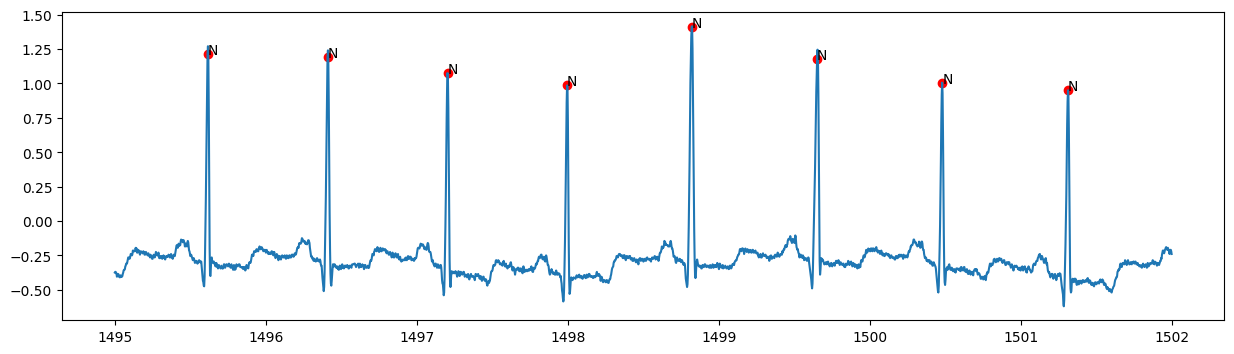

In [ ]:
start, end = 1495*360, 1502*360  # zoom into ~1495-1502s
sig = record.p_signal[start:end, 0]
time = np.arange(start, end) / record.fs

mask = (annotation.sample >= start) & (annotation.sample < end)
ann_samples = annotation.sample[mask]
ann_symbols = np.array(annotation.symbol)[mask]

plt.figure(figsize=(15, 4))
plt.plot(time, sig)
plt.scatter(ann_samples / record.fs, sig[ann_samples - start], color='red')
for s, sym in zip(ann_samples, ann_symbols):
    plt.annotate(sym, (s / record.fs, sig[s - start]))
plt.show()

Minimum value: -2.715
At sample index: 546792 -> time (s): 1518.8666666666666


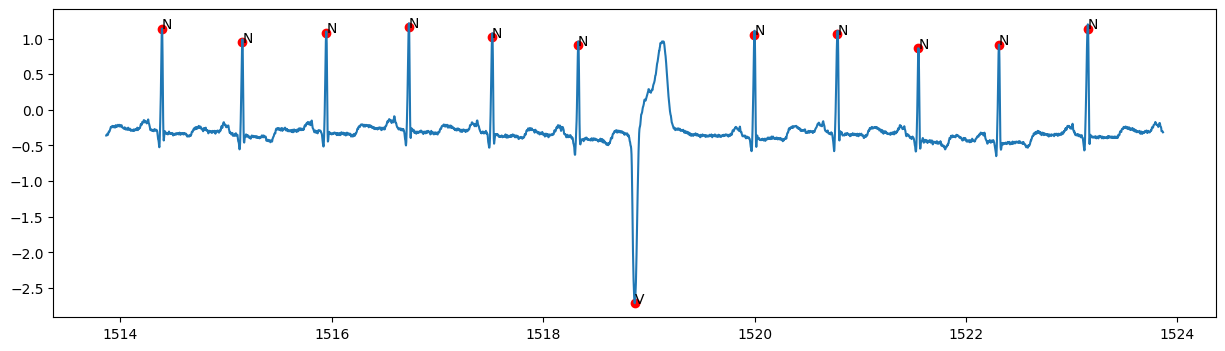

In [ ]:
# Find the exact sample index of the minimum value in the whole signal
min_idx = np.argmin(record.p_signal[:, 0])
min_time = min_idx / record.fs
print("Minimum value:", record.p_signal[min_idx, 0])
print("At sample index:", min_idx, "-> time (s):", min_time)

# Now zoom exactly around that
start = max(0, min_idx - 5*360)
end = min_idx + 5*360
sig = record.p_signal[start:end, 0]
time = np.arange(start, end) / record.fs

mask = (annotation.sample >= start) & (annotation.sample < end)
ann_samples = annotation.sample[mask]
ann_symbols = np.array(annotation.symbol)[mask]

plt.figure(figsize=(15, 4))
plt.plot(time, sig)
plt.scatter(ann_samples / record.fs, sig[ann_samples - start], color='red')
for s, sym in zip(ann_samples, ann_symbols):
    plt.annotate(sym, (s / record.fs, sig[s - start]))
plt.show()

**loading all records**

In [ ]:
import wfdb
from collections import Counter

# List of all 48 MIT-BIH record names
record_names = ['100','101','102','103','104','105','106','107','108','109',
                 '111','112','113','114','115','116','117','118','119','121',
                 '122','123','124','200','201','202','203','205','207','208',
                 '209','210','212','213','214','215','217','219','220','221',
                 '222','223','228','230','231','232','233','234']

# Download all records
wfdb.dl_database('mitdb', dl_dir='mitdb_data', records=record_names)

# Collect symbol counts across all records
total_counter = Counter()
per_record_counts = {}

for rec_name in record_names:
    ann = wfdb.rdann(f'mitdb_data/{rec_name}', 'atr')
    counts = Counter(ann.symbol)
    per_record_counts[rec_name] = counts
    total_counter.update(counts)

print("=== TOTAL SYMBOL DISTRIBUTION ACROSS ALL 48 RECORDS ===")
for symbol, count in total_counter.most_common():
    print(f"{symbol}: {count}")

print("\nTotal annotations:", sum(total_counter.values()))

Generating record list for: 100
Generating record list for: 101
Generating record list for: 102
Generating record list for: 103
Generating record list for: 104
Generating record list for: 105
Generating record list for: 106
Generating record list for: 107
Generating record list for: 108
Generating record list for: 109
Generating record list for: 111
Generating record list for: 112
Generating record list for: 113
Generating record list for: 114
Generating record list for: 115
Generating record list for: 116
Generating record list for: 117
Generating record list for: 118
Generating record list for: 119
Generating record list for: 121
Generating record list for: 122
Generating record list for: 123
Generating record list for: 124
Generating record list for: 200
Generating record list for: 201
Generating record list for: 202
Generating record list for: 203
Generating record list for: 205
Generating record list for: 207
Generating record list for: 208
Generating record list for: 209
Generati

In [ ]:
import wfdb
import pandas as pd
from collections import Counter

record_names = ['100','101','102','103','104','105','106','107','108','109',
                 '111','112','113','114','115','116','117','118','119','121',
                 '122','123','124','200','201','202','203','205','207','208',
                 '209','210','212','213','214','215','217','219','220','221',
                 '222','223','228','230','231','232','233','234']

# AAMI symbol groups
aami_map = {
    'N': ['N', 'L', 'R', 'e', 'j'],
    'S': ['A', 'a', 'J', 'S'],
    'V': ['V', 'E'],
    'F': ['F'],
    'Q': ['/', 'f', 'Q'],
}

# invert map for quick lookup
symbol_to_class = {}
for cls, syms in aami_map.items():
    for s in syms:
        symbol_to_class[s] = cls

rows = []
for rec_name in record_names:
    ann = wfdb.rdann(f'mitdb_data/{rec_name}', 'atr')
    counts = Counter(ann.symbol)

    class_counts = {'N': 0, 'S': 0, 'V': 0, 'F': 0, 'Q': 0}
    for sym, cnt in counts.items():
        cls = symbol_to_class.get(sym)
        if cls:
            class_counts[cls] += cnt

    row = {'record': rec_name}
    row.update(class_counts)
    row['total_beats'] = sum(class_counts.values())
    rows.append(row)

df = pd.DataFrame(rows)
df = df.set_index('record')

print("=== PER-RECORD AAMI CLASS BREAKDOWN ===")
print(df)

print("\n=== Records containing S beats ===")
print(df[df['S'] > 0]['S'].sort_values(ascending=False))

print("\n=== Records containing F beats ===")
print(df[df['F'] > 0]['F'].sort_values(ascending=False))

print("\n=== Records containing Q beats (includes paced /) ===")
print(df[df['Q'] > 0]['Q'].sort_values(ascending=False))

# Specifically check paced beats ('/') separately since they dominate Q
print("\n=== Records containing PACED beats ('/') specifically ===")
paced_rows = []
for rec_name in record_names:
    ann = wfdb.rdann(f'mitdb_data/{rec_name}', 'atr')
    counts = Counter(ann.symbol)
    if counts.get('/', 0) > 0:
        paced_rows.append({'record': rec_name, 'paced_count': counts['/']})
paced_df = pd.DataFrame(paced_rows).set_index('record').sort_values('paced_count', ascending=False)
print(paced_df)

# Save this to CSV so you can reference it later when building the split
df.to_csv('per_record_aami_counts.csv')
print("\nSaved to per_record_aami_counts.csv")

=== PER-RECORD AAMI CLASS BREAKDOWN ===
           N     S    V    F     Q  total_beats
record                                         
100     2239    33    1    0     0         2273
101     1860     3    0    0     2         1865
102       99     0    4    0  2084         2187
103     2082     2    0    0     0         2084
104      163     0    2    0  2064         2229
105     2526     0   41    0     5         2572
106     1507     0  520    0     0         2027
107        0     0   59    0  2078         2137
108     1740     4   17    2     0         1763
109     2492     0   38    2     0         2532
111     2123     0    1    0     0         2124
112     2537     2    0    0     0         2539
113     1789     6    0    0     0         1795
114     1820    12   43    4     0         1879
115     1953     0    0    0     0         1953
116     2302     1  109    0     0         2412
117     1534     1    0    0     0         1535
118     2166    96   16    0     0         2278


In [ ]:
ds1 = [101,106,108,109,112,114,115,116,118,119,122,124,201,203,205,207,208,209,215,220,223,230]
ds2 = [100,103,105,111,113,117,121,123,200,202,210,212,213,214,219,221,222,228,231,232,233,234]

ds1 = [str(r) for r in ds1]
ds2 = [str(r) for r in ds2]

print("=== DS1 (train) class totals ===")
print(df.loc[ds1, ['N','S','V','F','Q']].sum())

print("\n=== DS2 (test) class totals ===")
print(df.loc[ds2, ['N','S','V','F','Q']].sum())

=== DS1 (train) class totals ===
N    45866
S      944
V     3788
F      415
Q        8
dtype: int64

=== DS2 (test) class totals ===
N    44259
S     1837
V     3221
F      388
Q        7
dtype: int64


**pre-processing**

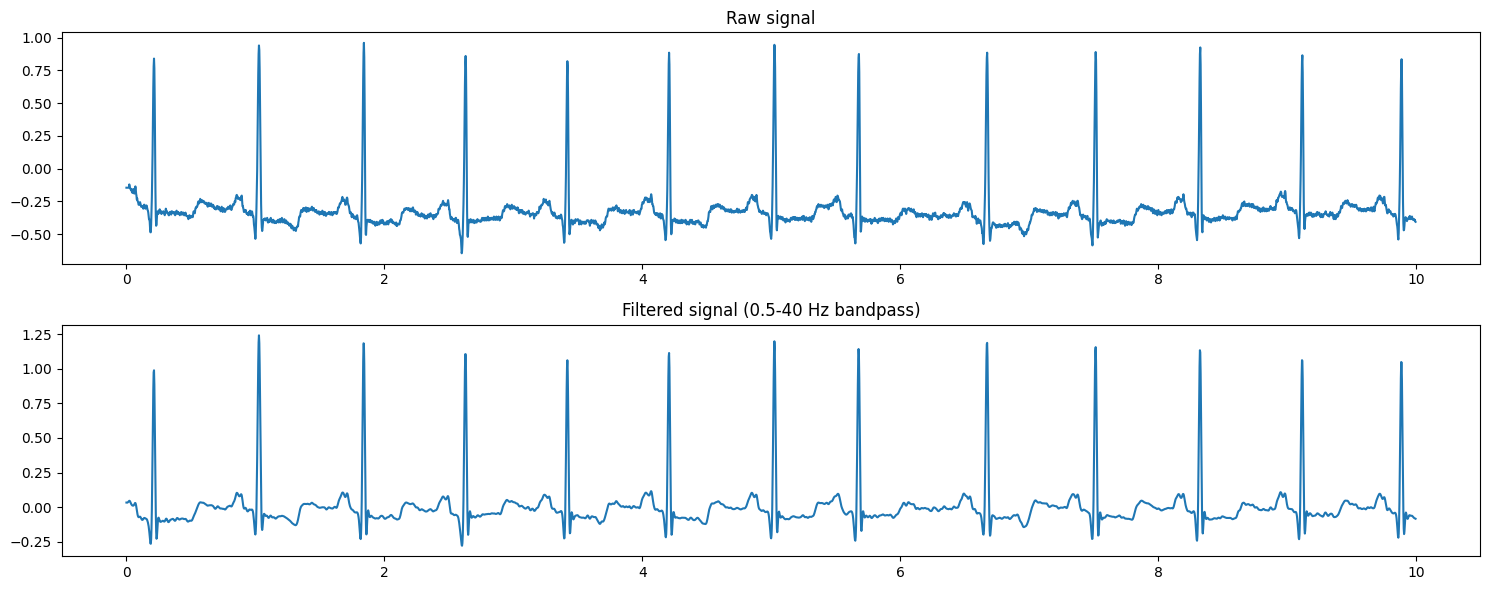

In [ ]:
#Filtering
#on record 100
from scipy.signal import butter, filtfilt
import numpy as np

def bandpass_filter(signal, fs, lowcut=0.5, highcut=40.0, order=4):
    nyquist = fs / 2
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    filtered = filtfilt(b, a, signal)  # zero-phase filtering — no time shift
    return filtered

record = wfdb.rdrecord('mitdb_data/100')
raw_signal = record.p_signal[:, 0]  # MLII channel
fs = record.fs

filtered_signal = bandpass_filter(raw_signal, fs)

# Compare a 10-second window, raw vs filtered
start, end = 0, 3600
time = np.arange(start, end) / fs

plt.figure(figsize=(15, 6))
plt.subplot(2, 1, 1)
plt.plot(time, raw_signal[start:end])
plt.title("Raw signal")

plt.subplot(2, 1, 2)
plt.plot(time, filtered_signal[start:end])
plt.title("Filtered signal (0.5-40 Hz bandpass)")
plt.tight_layout()
plt.show()

#normalization
def normalize(signal):
    return (signal - np.mean(signal)) / np.std(signal)

normalized_signal = normalize(filtered_signal)

In [ ]:
#filtering across few records
def load_and_preprocess(record_name, data_dir='mitdb_data'):
    record = wfdb.rdrecord(f'{data_dir}/{record_name}')
    raw_signal = record.p_signal[:, 0]  # MLII channel
    fs = record.fs

    filtered = bandpass_filter(raw_signal, fs)
    normalized = normalize(filtered)

    return normalized, fs, record

# Quick test across a few records including a noisier one
for rec in ['100', '108', '203']:
    sig, fs, rec_obj = load_and_preprocess(rec)
    print(f"Record {rec}: mean={sig.mean():.4f}, std={sig.std():.4f}, shape={sig.shape}")

Record 100: mean=0.0000, std=1.0000, shape=(650000,)
Record 108: mean=0.0000, std=1.0000, shape=(650000,)
Record 203: mean=0.0000, std=1.0000, shape=(650000,)


**R-peak Detection (Pan-Tompkins)**

In [ ]:
#1.Band pass filtering already done above
#2.Derivative
def derivative_filter(signal):
    # 5-point derivative, standard Pan-Tompkins coefficients
    return np.diff(signal, prepend=signal[0])

def derivative_filter(signal, fs):
    # Pan-Tompkins derivative: y[n] = (1/8T)(-x[n-2]-2x[n-1]+2x[n+1]+x[n+2])
    b = np.array([1, 2, 0, -2, -1]) * (fs / 8.0)
    return np.convolve(signal, b, mode='same')

#3.Squaring
def squaring(signal):
    return signal ** 2

#4.Moving window integration
def moving_window_integration(signal, fs, window_ms=150):
    window_size = int(window_ms / 1000 * fs)
    window = np.ones(window_size) / window_size
    return np.convolve(signal, window, mode='same')

from scipy.signal import find_peaks

#5.Adaptive thresholding + Peak detection
def detect_r_peaks(filtered_signal, fs):
    derivative = derivative_filter(filtered_signal, fs)
    squared = squaring(derivative)
    integrated = moving_window_integration(squared, fs)

    # Minimum distance between peaks ~200ms (physiological limit on heart rate ~300bpm)
    min_distance = int(0.2 * fs)

    # Adaptive threshold: fraction of the signal's max, updated could be more sophisticated,
    # but this simple version works reasonably on MIT-BIH
    threshold = 0.3 * np.max(integrated)

    peaks, _ = find_peaks(integrated, height=threshold, distance=min_distance)

    # Refine: search a small window around each detected peak in the ORIGINAL filtered signal
    # to find the true local maximum (integration stage smears/shifts the peak location)
    refined_peaks = []
    search_radius = int(0.05 * fs)  # 50ms window
    for p in peaks:
        start = max(0, p - search_radius)
        end = min(len(filtered_signal), p + search_radius)
        local_peak = start + np.argmax(filtered_signal[start:end])
        refined_peaks.append(local_peak)

    return np.array(refined_peaks)

Number of detected peaks: 2273
Number of true annotated beats: 2273


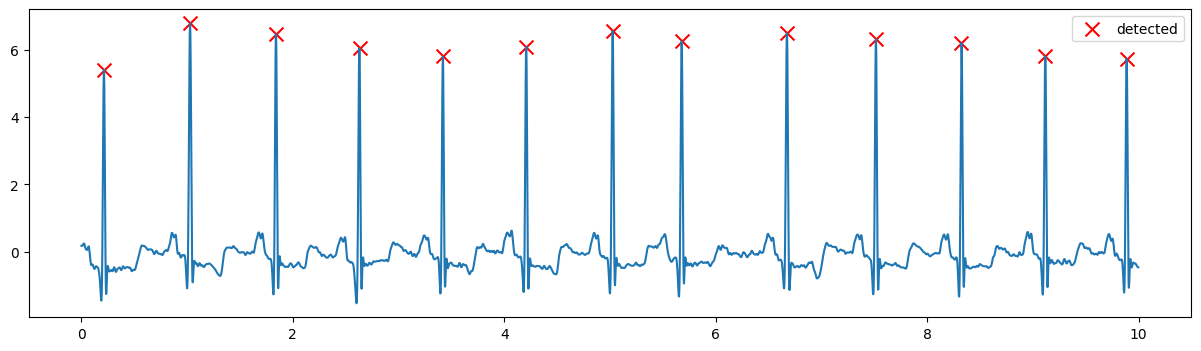

In [ ]:
#TESTING ON RECORD 100
sig, fs, rec_obj = load_and_preprocess('100')
detected_peaks = detect_r_peaks(sig, fs)

print(f"Number of detected peaks: {len(detected_peaks)}")

ann = wfdb.rdann('mitdb_data/100', 'atr')
true_beats = [s for s, sym in zip(ann.sample, ann.symbol) if sym not in ['+','~','!','"','|','[',']','x']]
print(f"Number of true annotated beats: {len(true_beats)}")

# Visual check on a short window
start, end = 0, 3600
plt.figure(figsize=(15,4))
plt.plot(np.arange(start,end)/fs, sig[start:end])
window_peaks = detected_peaks[(detected_peaks>=start)&(detected_peaks<end)]
plt.scatter(window_peaks/fs, sig[window_peaks], color='red', marker='x', s=100, label='detected')
plt.legend()
plt.show()

In [ ]:
#validations against ground truth
def validate_detection(detected_peaks, true_peaks, fs, tolerance_ms=75):
    tolerance = int(tolerance_ms / 1000 * fs)

    true_peaks = np.array(true_peaks)
    detected_peaks = np.array(detected_peaks)

    matched_true = np.zeros(len(true_peaks), dtype=bool)
    matched_detected = np.zeros(len(detected_peaks), dtype=bool)

    for i, tp in enumerate(true_peaks):
        # find closest detected peak within tolerance that hasn't been matched yet
        diffs = np.abs(detected_peaks - tp)
        candidates = np.where((diffs <= tolerance) & (~matched_detected))[0]
        if len(candidates) > 0:
            # pick the closest one
            best = candidates[np.argmin(diffs[candidates])]
            matched_true[i] = True
            matched_detected[best] = True

    TP = matched_true.sum()
    FN = (~matched_true).sum()
    FP = (~matched_detected).sum()

    sensitivity = TP / (TP + FN) if (TP+FN) > 0 else 0
    ppv = TP / (TP + FP) if (TP+FP) > 0 else 0

    return {'TP': TP, 'FN': FN, 'FP': FP, 'sensitivity': sensitivity, 'ppv': ppv}

# Test on record 100
result = validate_detection(detected_peaks, true_beats, fs)
print(result)

#test on several records
test_records = ['100', '101', '105', '108', '111', '203', '213', '234']

print(f"{'Record':<8}{'TP':<8}{'FN':<8}{'FP':<8}{'Sens':<10}{'PPV':<10}")
for rec in test_records:
    sig, fs, rec_obj = load_and_preprocess(rec)
    detected = detect_r_peaks(sig, fs)

    ann = wfdb.rdann(f'mitdb_data/{rec}', 'atr')
    true_b = [s for s, sym in zip(ann.sample, ann.symbol) if sym not in ['+','~','!','"','|','[',']','x']]

    res = validate_detection(detected, true_b, fs)
    print(f"{rec:<8}{res['TP']:<8}{res['FN']:<8}{res['FP']:<8}{res['sensitivity']:<10.4f}{res['ppv']:<10.4f}")

{'TP': np.int64(2273), 'FN': np.int64(0), 'FP': np.int64(0), 'sensitivity': np.float64(1.0), 'ppv': np.float64(1.0)}
Record  TP      FN      FP      Sens      PPV       
100     2273    0       0       1.0000    1.0000    
101     1812    53      5       0.9716    0.9972    
105     4       2568    2       0.0016    0.6667    
108     715     1048    1       0.4056    0.9986    
111     1522    602     0       0.7166    1.0000    
203     87      2893    40      0.0292    0.6850    
213     3226    25      0       0.9923    1.0000    
234     2739    14      0       0.9949    1.0000    


In [ ]:
def detect_r_peaks_adaptive(filtered_signal, fs):
    derivative = derivative_filter(filtered_signal, fs)
    squared = squaring(derivative)
    integrated = moving_window_integration(squared, fs)

    min_distance = int(0.2 * fs)

    # Initialize adaptive thresholds using the first 2 seconds as a learning period
    init_window = integrated[:2*fs]
    SPKI = np.max(init_window) * 0.25   # running estimate of signal peak level
    NPKI = np.mean(init_window) * 0.5   # running estimate of noise peak level
    threshold1 = NPKI + 0.25 * (SPKI - NPKI)

    peaks = []
    last_peak = -min_distance

    # Find all local maxima candidates first
    candidate_peaks, _ = find_peaks(integrated, distance=min_distance)

    for p in candidate_peaks:
        peak_val = integrated[p]

        if peak_val > threshold1:
            # classified as a QRS peak -> update signal level estimate
            SPKI = 0.125 * peak_val + 0.875 * SPKI
            peaks.append(p)
        else:
            # classified as noise -> update noise level estimate
            NPKI = 0.125 * peak_val + 0.875 * NPKI

        # recompute threshold after every candidate peak (this is the "adaptive" part)
        threshold1 = NPKI + 0.25 * (SPKI - NPKI)

    # Refine to true local max in filtered signal, same as before
    refined_peaks = []
    search_radius = int(0.05 * fs)
    for p in peaks:
        start = max(0, p - search_radius)
        end = min(len(filtered_signal), p + search_radius)
        local_peak = start + np.argmax(filtered_signal[start:end])
        refined_peaks.append(local_peak)

    return np.array(refined_peaks)

print(f"{'Record':<8}{'TP':<8}{'FN':<8}{'FP':<8}{'Sens':<10}{'PPV':<10}")
for rec in test_records:
    sig, fs, rec_obj = load_and_preprocess(rec)
    detected = detect_r_peaks_adaptive(sig, fs)

    ann = wfdb.rdann(f'mitdb_data/{rec}', 'atr')
    true_b = [s for s, sym in zip(ann.sample, ann.symbol) if sym not in ['+','~','!','"','|','[',']','x']]

    res = validate_detection(detected, true_b, fs)
    print(f"{rec:<8}{res['TP']:<8}{res['FN']:<8}{res['FP']:<8}{res['sensitivity']:<10.4f}{res['ppv']:<10.4f}")

Record  TP      FN      FP      Sens      PPV       
100     2273    0       0       1.0000    1.0000    
101     1863    2       7       0.9989    0.9963    
105     2559    13      83      0.9949    0.9686    
108     1730    33      256     0.9813    0.8711    
111     2118    6       7       0.9972    0.9967    
203     2880    100     130     0.9664    0.9568    
213     3243    8       0       0.9975    1.0000    
234     2748    5       0       0.9982    1.0000    


In [ ]:
import time
# 44 non-paced records (excluding 102, 104, 107, 217)
all_records = ['100','101','103','105','106','108','109',
               '111','112','113','114','115','116','117','118','119','121',
               '122','123','124','200','201','202','203','205','207','208',
               '209','210','212','213','214','215','219','220','221',
               '222','223','228','230','231','232','233','234']

print(f"Validating detection across all {len(all_records)} records...")
print(f"{'Record':<8}{'TP':<8}{'FN':<8}{'FP':<8}{'Sens':<10}{'PPV':<10}")

results = []
start_time = time.time()

for rec in all_records:
    sig, fs, rec_obj = load_and_preprocess(rec)
    detected = detect_r_peaks_adaptive(sig, fs)

    ann = wfdb.rdann(f'mitdb_data/{rec}', 'atr')
    true_b = [s for s, sym in zip(ann.sample, ann.symbol) if sym not in ['+','~','!','"','|','[',']','x']]

    res = validate_detection(detected, true_b, fs)
    res['record'] = rec
    results.append(res)

    print(f"{rec:<8}{res['TP']:<8}{res['FN']:<8}{res['FP']:<8}{res['sensitivity']:<10.4f}{res['ppv']:<10.4f}")

elapsed = time.time() - start_time
print(f"\nCompleted in {elapsed:.1f} seconds")

# Aggregate stats
results_df = pd.DataFrame(results).set_index('record')

total_TP = results_df['TP'].sum()
total_FN = results_df['FN'].sum()
total_FP = results_df['FP'].sum()

overall_sensitivity = total_TP / (total_TP + total_FN)
overall_ppv = total_TP / (total_TP + total_FP)

print(f"\n=== OVERALL (pooled across all beats) ===")
print(f"Total TP: {total_TP}, FN: {total_FN}, FP: {total_FP}")
print(f"Overall Sensitivity: {overall_sensitivity:.4f}")
print(f"Overall PPV: {overall_ppv:.4f}")

print(f"\n=== MEAN PER-RECORD (unweighted average across records) ===")
print(f"Mean Sensitivity: {results_df['sensitivity'].mean():.4f}")
print(f"Mean PPV: {results_df['ppv'].mean():.4f}")

# Show the worst-performing records — worth discussing explicitly in your report
print(f"\n=== 5 WORST RECORDS BY SENSITIVITY ===")
print(results_df.sort_values('sensitivity').head(5)[['TP','FN','FP','sensitivity','ppv']])

print(f"\n=== 5 WORST RECORDS BY PPV ===")
print(results_df.sort_values('ppv').head(5)[['TP','FN','FP','sensitivity','ppv']])

results_df.to_csv('detection_validation_results.csv')
print("\nSaved to detection_validation_results.csv")

Validating detection across all 44 records...
Record  TP      FN      FP      Sens      PPV       
100     2273    0       0       1.0000    1.0000    
101     1863    2       7       0.9989    0.9963    
103     2079    5       0       0.9976    1.0000    
105     2559    13      83      0.9949    0.9686    
106     1991    36      2       0.9822    0.9990    
108     1730    33      256     0.9813    0.8711    
109     2525    7       4       0.9972    0.9984    
111     2118    6       7       0.9972    0.9967    
112     2539    0       2       1.0000    0.9992    
113     1795    0       0       1.0000    1.0000    
114     1859    20      26      0.9894    0.9862    
115     1953    0       0       1.0000    1.0000    
116     2385    27      4       0.9888    0.9983    
117     1535    0       0       1.0000    1.0000    
118     2277    1       6       0.9996    0.9974    
119     1987    0       1       1.0000    0.9995    
121     1861    2       4       0.9989    0.9979    


**phase 4**

In [ ]:
import numpy as np
import wfdb
from collections import Counter

# AAMI mapping — reused from Phase 1
aami_map = {
    'N': ['N', 'L', 'R', 'e', 'j'],
    'S': ['A', 'a', 'J', 'S'],
    'V': ['V', 'E'],
    'F': ['F'],
}
symbol_to_class = {}
for cls, syms in aami_map.items():
    for s in syms:
        symbol_to_class[s] = cls

class_to_idx = {'N': 0, 'S': 1, 'V': 2, 'F': 3}

DS1 = [101,106,108,109,112,114,115,116,118,119,122,124,201,203,205,207,208,209,215,220,223,230]
DS2 = [100,103,105,111,113,117,121,123,200,202,210,212,213,214,219,221,222,228,231,232,233,234]

PRE = 90
POST = 110

def extract_beats(record_name, data_dir='mitdb_data'):
    record = wfdb.rdrecord(f'{data_dir}/{record_name}')
    raw_signal = record.p_signal[:, 0]  # MLII channel
    fs = record.fs
    filtered = bandpass_filter(raw_signal, fs)
    normalized = normalize(filtered)

    ann = wfdb.rdann(f'{data_dir}/{record_name}', 'atr')

    X, y = [], []
    for sample, symbol in zip(ann.sample, ann.symbol):
        cls = symbol_to_class.get(symbol)
        if cls is None:
            continue  # skip Q-class and non-beat markers

        start = sample - PRE
        end = sample + POST
        if start < 0 or end > len(normalized):
            continue  # skip beats too close to record edges

        window = normalized[start:end]
        X.append(window)
        y.append(class_to_idx[cls])

    return np.array(X), np.array(y)

def build_dataset(record_list):
    all_X, all_y = [], []
    for rec in record_list:
        X, y = extract_beats(str(rec))
        all_X.append(X)
        all_y.append(y)
    return np.concatenate(all_X), np.concatenate(all_y)

print("Building DS1 (train)...")
X_train, y_train = build_dataset(DS1)

print("Building DS2 (test)...")
X_test, y_test = build_dataset(DS2)

print(f"\nX_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

print("\nTrain class distribution:", Counter(y_train))
print("Test class distribution:", Counter(y_test))

# Save for reuse in Phase 5 (model training) so you don't rebuild every session
np.savez('ecg_dataset.npz', X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test)
print("\nSaved to ecg_dataset.npz")

Building DS1 (train)...
Building DS2 (test)...

X_train shape: (51000, 200), y_train shape: (51000,)
X_test shape: (49690, 200), y_test shape: (49690,)

Train class distribution: Counter({np.int64(0): 45854, np.int64(2): 3788, np.int64(1): 944, np.int64(3): 414})
Test class distribution: Counter({np.int64(0): 44245, np.int64(2): 3220, np.int64(1): 1837, np.int64(3): 388})

Saved to ecg_dataset.npz


**model building and training**

In [ ]:
#1.computing class weights
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.array([0, 1, 2, 3])
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

#2. Building 1D-CNN
import tensorflow as tf
from tensorflow.keras import layers, models

def build_model(input_length=200, num_classes=4):
    model = models.Sequential([
        layers.Input(shape=(input_length, 1)),

        layers.Conv1D(16, kernel_size=7, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(32, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),

        layers.Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling1D(),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

#3. Reshaping the data and training
# CNN expects (samples, timesteps, channels)
X_train_r = X_train.reshape(-1, 200, 1)
X_test_r = X_test.reshape(-1, 200, 1)

history = model.fit(
    X_train_r, y_train,
    validation_data=(X_test_r, y_test),
    epochs=20,
    batch_size=128,
    class_weight=class_weight_dict,
    verbose=1
)

Class weights: {np.int64(0): np.float64(0.278056440005234), np.int64(1): np.float64(13.50635593220339), np.int64(2): np.float64(3.3658922914466736), np.int64(3): np.float64(30.797101449275363)}


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 16)        │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 100, 32)        │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 100, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 50, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 50, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,588 (45.27 KB)

 Trainable params: 11,364 (44.39 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 28s 62ms/step - accuracy: 0.5528 - loss: 0.7695 - val_accuracy: 0.5060 - val_loss: 0.8888
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 29s 73ms/step - accuracy: 0.7844 - loss: 0.4900 - val_accuracy: 0.7750 - val_loss: 0.6210
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 27s 67ms/step - accuracy: 0.8305 - loss: 0.4089 - val_accuracy: 0.7479 - val_loss: 0.7375
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.8552 - loss: 0.3643 - val_accuracy: 0.8050 - val_loss: 0.6604
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 37s 63ms/step - accuracy: 0.8837 - loss: 0.3301 - val_accuracy: 0.6635 - val_loss: 1.2028
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.8926 - loss: 0.2882 - val_accuracy: 0.7697 - val_loss: 0.7743
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.9018 - loss: 0.2784 - val_accuracy: 0.6381 - val_loss: 1.1404
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.9030 - loss: 0.2574 - 

In [ ]:
#making some fixes for the above displayed output
class_weight_dict = {k: min(v, 10.0) for k, v in class_weight_dict.items()}
print(class_weight_dict)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

#rebuilding-retraining
model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

capped_weights = {k: min(v, 10.0) for k, v in class_weight_dict.items()}
print("Capped class weights:", capped_weights)

history = model.fit(
    X_train_r, y_train,
    validation_data=(X_test_r, y_test),
    epochs=40,
    batch_size=128,
    class_weight=capped_weights,
    callbacks=callbacks,
    verbose=1
)

{np.int64(0): np.float64(0.278056440005234), np.int64(1): 10.0, np.int64(2): np.float64(3.3658922914466736), np.int64(3): 10.0}
Capped class weights: {np.int64(0): np.float64(0.278056440005234), np.int64(1): 10.0, np.int64(2): np.float64(3.3658922914466736), np.int64(3): 10.0}
Epoch 1/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 30s 63ms/step - accuracy: 0.6483 - loss: 0.6725 - val_accuracy: 0.4022 - val_loss: 1.0731 - learning_rate: 3.0000e-04
Epoch 2/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 25s 62ms/step - accuracy: 0.8185 - loss: 0.4521 - val_accuracy: 0.8756 - val_loss: 0.5561 - learning_rate: 3.0000e-04
Epoch 3/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 41s 61ms/step - accuracy: 0.8731 - loss: 0.3503 - val_accuracy: 0.8473 - val_loss: 0.5194 - learning_rate: 3.0000e-04
Epoch 4/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 25s 63ms/step - accuracy: 0.8929 - loss: 0.2975 - val_accuracy: 0.8504 - val_loss: 0.5123 - learning_rate: 3.0000e-04
Epoch 5/40
399/399 ━━━━━━━━━━━━━━━━━━━━ 40s 62ms/step - accuracy: 0.9032 - loss: 0.2634 - 

**phase6**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

y_pred_probs = model.predict(X_test_r)
y_pred = np.argmax(y_pred_probs, axis=1)

class_names = ['N', 'S', 'V', 'F']

print("=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix ===")
print("Rows = true, Columns = predicted")
print(pd.DataFrame(cm, index=class_names, columns=class_names))

def per_class_specificity(cm, class_names):
    results = {}
    total = cm.sum()
    for i, name in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = total - TP - FN - FP
        specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
        results[name] = specificity
    return results

spec = per_class_specificity(cm, class_names)
print("\n=== Per-class Specificity ===")
for k, v in spec.items():
    print(f"{k}: {v:.4f}")

from sklearn.metrics import f1_score
macro_f1 = f1_score(y_test, y_pred, average='macro')
print(f"\nMacro-F1: {macro_f1:.4f}")

1553/1553 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step
=== Classification Report ===
              precision    recall  f1-score   support

           N     0.9532    0.8844    0.9175     44245
           S     0.0273    0.0365    0.0312      1837
           V     0.5793    0.9497    0.7196      3220
           F     0.0000    0.0000    0.0000       388

    accuracy                         0.8504     49690
   macro avg     0.3899    0.4676    0.4171     49690
weighted avg     0.8873    0.8504    0.8647     49690


=== Confusion Matrix ===
Rows = true, Columns = predicted
       N     S     V    F
N  39129  2389  1862  865
S   1519    67   227   24
V    146     0  3058   16
F    256     0   132    0

=== Per-class Specificity ===
N: 0.6472
S: 0.9501
V: 0.9522
F: 0.9816

Macro-F1: 0.4171


In [ ]:
import numpy as np
import wfdb
from collections import Counter

# AAMI mapping — reused from Phase 1
aami_map = {
    'N': ['N', 'L', 'R', 'e', 'j'],
    'S': ['A', 'a', 'J', 'S'],
    'V': ['V', 'E'],
    'F': ['F'],
}
symbol_to_class = {}
for cls, syms in aami_map.items():
    for s in syms:
        symbol_to_class[s] = cls

class_to_idx = {'N': 0, 'S': 1, 'V': 2, 'F': 3}

DS1 = [101,106,108,109,112,114,115,116,118,119,122,124,201,203,205,207,208,209,215,220,223,230]
DS2 = [100,103,105,111,113,117,121,123,200,202,210,212,213,214,219,221,222,228,231,232,233,234]

PRE = 90
POST = 110

def extract_beats_with_rr(record_name, data_dir='mitdb_data'):
    record = wfdb.rdrecord(f'{data_dir}/{record_name}')
    raw_signal = record.p_signal[:, 0]  # MLII channel
    fs = record.fs
    filtered = bandpass_filter(raw_signal, fs)
    normalized = normalize(filtered)

    ann = wfdb.rdann(f'{data_dir}/{record_name}', 'atr')

    # Keep only actual beats (filter out +, ~, etc.) but track ALL beat samples
    # in order, since RR intervals need the true previous/next beat regardless of class
    beat_samples = []
    beat_symbols = []
    for sample, symbol in zip(ann.sample, ann.symbol):
        if symbol in symbol_to_class or symbol == 'N':  # any real beat symbol
            beat_samples.append(sample)
            beat_symbols.append(symbol)

    X_wave, X_rr, y = [], [], []

    for i in range(1, len(beat_samples) - 1):  # skip first/last: need prev AND next
        symbol = beat_symbols[i]
        cls = symbol_to_class.get(symbol)
        if cls is None:
            continue

        sample = beat_samples[i]
        start = sample - PRE
        end = sample + POST
        if start < 0 or end > len(normalized):
            continue

        window = normalized[start:end]

        # RR features (in seconds)
        prev_rr = (beat_samples[i] - beat_samples[i-1]) / fs
        next_rr = (beat_samples[i+1] - beat_samples[i]) / fs

        # local average RR over up to last 10 beats (excluding current)
        local_window = beat_samples[max(0, i-10):i]
        if len(local_window) >= 2:
            local_avg_rr = np.mean(np.diff(local_window)) / fs
        else:
            local_avg_rr = prev_rr

        ratio_rr = prev_rr / local_avg_rr if local_avg_rr > 0 else 1.0

        X_wave.append(window)
        X_rr.append([prev_rr, next_rr, local_avg_rr, ratio_rr])
        y.append(class_to_idx[cls])

    return np.array(X_wave), np.array(X_rr), np.array(y)

def build_dataset_with_rr(record_list):
    all_Xw, all_Xrr, all_y = [], [], []
    for rec in record_list:
        Xw, Xrr, y = extract_beats_with_rr(str(rec))
        all_Xw.append(Xw)
        all_Xrr.append(Xrr)
        all_y.append(y)
    return np.concatenate(all_Xw), np.concatenate(all_Xrr), np.concatenate(all_y)

print("Building DS1 (train) with RR features...")
Xw_train, Xrr_train, y_train = build_dataset_with_rr(DS1)

print("Building DS2 (test) with RR features...")
Xw_test, Xrr_test, y_test = build_dataset_with_rr(DS2)

print(f"\nXw_train shape: {Xw_train.shape}, Xrr_train shape: {Xrr_train.shape}, y_train shape: {y_train.shape}")
print(f"Xw_test shape: {Xw_test.shape}, Xrr_test shape: {Xrr_test.shape}, y_test shape: {y_test.shape}")

print("\nTrain class distribution:", Counter(y_train))
print("Test class distribution:", Counter(y_test))

# Save for reuse
np.savez('ecg_dataset_rr.npz', Xw_train=Xw_train, Xrr_train=Xrr_train, y_train=y_train,
         Xw_test=Xw_test, Xrr_test=Xrr_test, y_test=y_test)
print("\nSaved to ecg_dataset_rr.npz")

Building DS1 (train) with RR features...
Building DS2 (test) with RR features...

Xw_train shape: (50969, 200), Xrr_train shape: (50969, 4), y_train shape: (50969,)
Xw_test shape: (49661, 200), Xrr_test shape: (49661, 4), y_test shape: (49661,)

Train class distribution: Counter({np.int64(0): 45824, np.int64(2): 3788, np.int64(1): 943, np.int64(3): 414})
Test class distribution: Counter({np.int64(0): 44218, np.int64(2): 3219, np.int64(1): 1836, np.int64(3): 388})

Saved to ecg_dataset_rr.npz


In [ ]:
rr_mean = Xrr_train.mean(axis=0)
rr_std = Xrr_train.std(axis=0)

Xrr_train_norm = (Xrr_train - rr_mean) / rr_std
Xrr_test_norm = (Xrr_test - rr_mean) / rr_std

Xw_train_r = Xw_train.reshape(-1, 200, 1)
Xw_test_r = Xw_test.reshape(-1, 200, 1)

from sklearn.utils.class_weight import compute_class_weight
class_weights2 = compute_class_weight(class_weight='balanced', classes=np.array([0,1,2,3]), y=y_train)
class_weight_dict2 = {k: min(v, 10.0) for k, v in dict(zip([0,1,2,3], class_weights2)).items()}
print("Class weights:", class_weight_dict2)

from tensorflow.keras import layers, models, Input
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

def build_hybrid_model(wave_length=200, rr_features=4, num_classes=4):
    wave_input = Input(shape=(wave_length, 1), name='waveform')
    # Reshape for TFLite Conv2D compatibility (add a height dimension of 1)
    x = layers.Reshape((1, wave_length, 1))(wave_input)

    x = layers.Conv2D(16, (7, 1), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Conv2D(32, (5, 1), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 1))(x)
    x = layers.Conv2D(64, (3, 1), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.GlobalAveragePooling2D()(x) # Adjust pooling for 2D output

    rr_input = Input(shape=(rr_features,), name='rr_features')
    r = layers.Dense(16, activation='relu')(rr_input)

    combined = layers.Concatenate()([x, r])
    combined = layers.Dense(32, activation='relu')(combined)
    combined = layers.Dropout(0.3)(combined)
    output = layers.Dense(num_classes, activation='softmax')(combined)

    model = models.Model(inputs=[wave_input, rr_input], outputs=output)
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

hybrid_model = build_hybrid_model()
hybrid_model.summary()

callbacks2 = [
    EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ModelCheckpoint('best_hybrid_model.keras', monitor='val_loss', save_best_only=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history2 = hybrid_model.fit(
    [Xw_train_r, Xrr_train_norm], y_train,
    validation_data=([Xw_test_r, Xrr_test_norm], y_test),
    epochs=40,
    batch_size=128,
    class_weight=class_weight_dict2,
    callbacks=callbacks2,
    verbose=1
)

Class weights: {0: np.float64(0.2780693523044693), 1: 10.0, 2: np.float64(3.3638463569165786), 3: 10.0}


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ waveform            │ (None, 200, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 200, 1) │          0 │ waveform[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 1, 200,    │        128 │ reshape_2[0][0]   │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1, 200,    │         64 │ conv2d_6[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 0, 200,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 0, 200,    │      2,592 │ max_pooling2d_4[… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 0, 200,    │        128 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 0, 200,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 0, 200,    │      6,208 │ max_pooling2d_5[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 0, 200,    │        256 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rr_features         │ (None, 4)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 16)        │         80 │ rr_features[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_3       │ (None, 80)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 32)        │      2,592 │ concatenate_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 32)        │          0 │ dense_16[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 4)         │        132 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 12,180 (47.58 KB)

 Trainable params: 11,956 (46.70 KB)

 Non-trainable params: 224 (896.00 B)

Epoch 1/40


ValueError: Exception encountered when calling MaxPooling2D.call().

[1mNegative dimension size caused by subtracting 2 from 1 for '{{node functional_6_1/max_pooling2d_4_1/MaxPool2d}} = MaxPool[T=DT_FLOAT, data_format="NHWC", explicit_paddings=[], ksize=[1, 2, 1, 1], padding="VALID", strides=[1, 2, 1, 1]](functional_6_1/batch_normalization_18_1/batchnorm/add_1)' with input shapes: [?,1,200,16].[0m

Arguments received by MaxPooling2D.call():
  • inputs=tf.Tensor(shape=(None, 1, 200, 16), dtype=float32)

In [ ]:
y_pred_probs2 = hybrid_model.predict([Xw_test_r, Xrr_test_norm])
y_pred2 = np.argmax(y_pred_probs2, axis=1)

class_names = ['N', 'S', 'V', 'F']

print("=== Classification Report (Hybrid Model) ===")
print(classification_report(y_test, y_pred2, target_names=class_names, digits=4))

cm2 = confusion_matrix(y_test, y_pred2)
print("\n=== Confusion Matrix ===")
print("Rows = true, Columns = predicted")
print(pd.DataFrame(cm2, index=class_names, columns=class_names))

spec2 = per_class_specificity(cm2, class_names)
print("\n=== Per-class Specificity ===")
for k, v in spec2.items():
    print(f"{k}: {v:.4f}")

macro_f1_2 = f1_score(y_test, y_pred2, average='macro')
print(f"\nMacro-F1: {macro_f1_2:.4f}")

1552/1552 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step
=== Classification Report (Hybrid Model) ===
              precision    recall  f1-score   support

           N     0.9799    0.9424    0.9608     44218
           S     0.1823    0.2102    0.1953      1836
           V     0.6523    0.9407    0.7704      3219
           F     0.0000    0.0000    0.0000       388

    accuracy                         0.9079     49661
   macro avg     0.4536    0.5233    0.4816     49661
weighted avg     0.9215    0.9079    0.9126     49661


=== Confusion Matrix ===
Rows = true, Columns = predicted
       N     S     V    F
N  41672  1602   588  356
S    468   386   965   17
V     65   124  3028    2
F    322     5    61    0

=== Per-class Specificity ===
N: 0.8429
S: 0.9638
V: 0.9652
F: 0.9924

Macro-F1: 0.4816


# ***save upto here so that nothing fails***

In [ ]:
hybrid_model.save('final_ecg_model.keras')

import json
report_dict = classification_report(y_test, y_pred2, target_names=class_names, digits=4, output_dict=True)
with open('classification_report.json', 'w') as f:
    json.dump(report_dict, f, indent=2)

np.save('confusion_matrix.npy', cm2)
print("Model and evaluation artifacts saved.")

# Define "false alarm" as: true label N but predicted as abnormal (S/V/F)
false_alarms = np.sum((y_test == 0) & (y_pred2 != 0))
total_minutes = 22 * 30  # DS2 has 22 records, each 30 min
fa_per_min = false_alarms / total_minutes
print(f"False alarms: {false_alarms}")
print(f"Total minutes: {total_minutes}")
print(f"False alarms per minute: {fa_per_min:.4f}")

Model and evaluation artifacts saved.
False alarms: 2546
Total minutes: 660
False alarms per minute: 3.8576


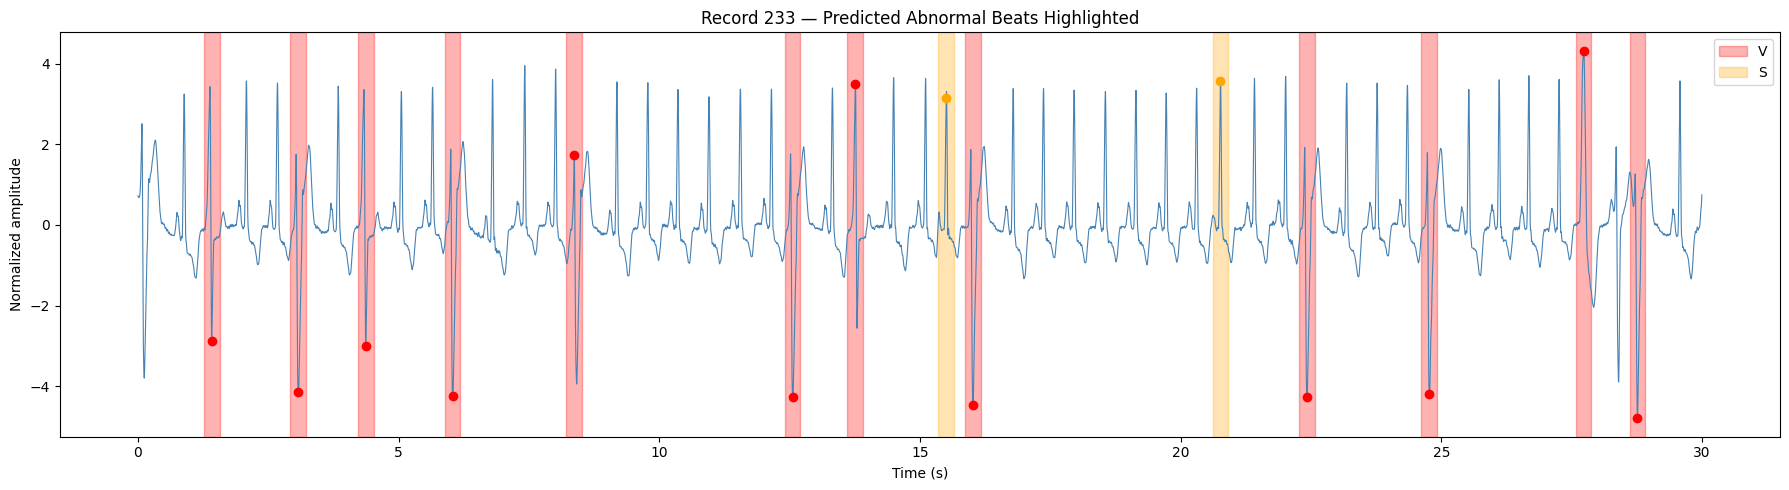

In [ ]:
def visualize_predictions(record_name, model, rr_mean, rr_std, data_dir='mitdb_data', duration_sec=30):
    record = wfdb.rdrecord(f'{data_dir}/{record_name}')
    raw_signal = record.p_signal[:, 0]
    fs = record.fs
    filtered = bandpass_filter(raw_signal, fs)
    normalized = normalize(filtered)

    ann = wfdb.rdann(f'{data_dir}/{record_name}', 'atr')
    beat_samples = [s for s, sym in zip(ann.sample, ann.symbol) if sym in symbol_to_class]
    beat_symbols = [sym for sym in ann.symbol if sym in symbol_to_class]

    # Build windows + RR features for beats within the display duration
    end_sample = duration_sec * fs
    X_wave, X_rr, positions, true_labels = [], [], [], []

    for i in range(1, len(beat_samples) - 1):
        sample = beat_samples[i]
        if sample > end_sample:
            break
        start, stop = sample - PRE, sample + POST
        if start < 0 or stop > len(normalized):
            continue

        prev_rr = (beat_samples[i] - beat_samples[i-1]) / fs
        next_rr = (beat_samples[i+1] - beat_samples[i]) / fs
        local_window = beat_samples[max(0, i-10):i]
        local_avg_rr = np.mean(np.diff(local_window))/fs if len(local_window) >= 2 else prev_rr
        ratio_rr = prev_rr / local_avg_rr if local_avg_rr > 0 else 1.0

        X_wave.append(normalized[start:stop])
        X_rr.append([prev_rr, next_rr, local_avg_rr, ratio_rr])
        positions.append(sample)
        true_labels.append(class_to_idx[symbol_to_class[beat_symbols[i]]])

    X_wave = np.array(X_wave).reshape(-1, 200, 1)
    X_rr = (np.array(X_rr) - rr_mean) / rr_std

    preds = np.argmax(model.predict([X_wave, X_rr], verbose=0), axis=1)

    # Plot
    time = np.arange(end_sample) / fs
    plt.figure(figsize=(18, 5))
    plt.plot(time, normalized[:end_sample], color='steelblue', linewidth=0.8)

    colors = {0: 'green', 1: 'orange', 2: 'red', 3: 'purple'}
    labels = {0: 'N', 1: 'S', 2: 'V', 3: 'F'}
    seen = set()
    for pos, pred in zip(positions, preds):
        if pred != 0:  # highlight only predicted-abnormal beats
            lbl = labels[pred] if pred not in seen else None
            seen.add(pred)
            plt.axvspan(pos/fs - 0.15, pos/fs + 0.15, color=colors[pred], alpha=0.3, label=lbl)
            plt.scatter(pos/fs, normalized[pos], color=colors[pred], zorder=5)

    plt.title(f"Record {record_name} — Predicted Abnormal Beats Highlighted")
    plt.xlabel("Time (s)")
    plt.ylabel("Normalized amplitude")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Try it on a record known to have abnormal beats in the test set, e.g. 233 (lots of V beats)
visualize_predictions('233', hybrid_model, rr_mean, rr_std, duration_sec=30)

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(hybrid_model)
tflite_model = converter.convert()

with open('ecg_model_float32.tflite', 'wb') as f:
    f.write(tflite_model)

import os
size_kb = os.path.getsize('ecg_model_float32.tflite') / 1024
print(f"Float32 TFLite model size: {size_kb:.2f} KB")

def representative_dataset():
    for i in range(min(200, len(Xw_train_r))):
        wave = Xw_train_r[i:i+1].astype(np.float32)
        rr = Xrr_train_norm[i:i+1].astype(np.float32)
        yield [wave, rr]

converter2 = tf.lite.TFLiteConverter.from_keras_model(hybrid_model)
converter2.optimizations = [tf.lite.Optimize.DEFAULT]
converter2.representative_dataset = representative_dataset
converter2.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter2.inference_input_type = tf.float32   # keep inputs as float32 for simplicity
converter2.inference_output_type = tf.float32

tflite_quant_model = converter2.convert()

with open('ecg_model_int8.tflite', 'wb') as f:
    f.write(tflite_quant_model)

size_kb_quant = os.path.getsize('ecg_model_int8.tflite') / 1024
print(f"Int8 quantized TFLite model size: {size_kb_quant:.2f} KB")
print(f"Size reduction: {(1 - size_kb_quant/size_kb)*100:.1f}%")

Saved artifact at '/tmp/tmpryh92r1g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): List[TensorSpec(shape=(None, 200, 1), dtype=tf.float32, name='waveform'), TensorSpec(shape=(None, 4), dtype=tf.float32, name='rr_features')]
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  140076489531536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140076489531344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140076489530960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140076489530768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140076489532112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140076489531152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140076489535376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140076489529424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140076489532496: TensorSpec(shape=(), dtype=tf.resource, name=None)
  140076489532304: Ten

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


RuntimeError: tensorflow/lite/kernels/conv.cc:345 input->dims->size != 4 (3 != 4)Node number 2 (CONV_2D) failed to prepare.